In [1]:
import pandas as pd

from Pipeline.Methodology.BayesianAnalysis import BayesianAnalysis
from Pipeline.Methodology import ABC_Testing

In [2]:
model_files = {
    "ABC RELM CV"   : "cleaned_ABC_RELM_CV_Algo_3_2_80SN_120MI_Results.csv",
    "MLP"           : "cleaned_MLP_Results.csv",
    "ELM"           : "cleaned_Best_Hidden_Nodes_Results.csv",
    "RELM"          : "cleaned_Grid_Optimization_Results.csv",
    "ABC RELM"      : "cleaned_ABC_RELM_Algo_3_2_80SN_120MI_Results.csv",
    "ABC RELM IE"   : "cleaned_ABC_RELM_Iter_Ensemble_Algo_3_2_80SN_120MI_Results.csv",
    "ABC RELM CE"   : "cleaned_ABC_RELM_CV_Ensemble_Algo_3_2_80SN_120MI_Results.csv",
    "RF"            : "cleaned_RF_Results.csv",
    "HGBC"          : "cleaned_HGBC_Results.csv",
    "LRC"           : "cleaned_LogReg_Classifier_Results.csv",
    "Linear SVC"    : "cleaned_LinearSVC_Results.csv",
}
baseline = [
    "MLP",
    "RELM",
    "HGBC",
    "RF",
    "ELM",
    "ABC RELM",
    "Linear SVC",
    "ABC RELM CE",
    "LRC",
    "ABC RELM IE",
]

In [3]:
unused_column = [
        'Hidden_Nodes', 'Lambda_Value',
        'Solution_Size', 'Trial_Limit', 'Max_Iteration',
        'Precision', 'Recall', 'NPV', 'Specificity',
        'F2-Score', 'Bal Accuracy'
    ]

In [4]:
result_summary = ABC_Testing.overall_result_summaries(model_files,unused_column)

[I/O Trace] Bayesian Summary Figure exported: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Report Figure\Bayesian_Summary_Bayesian_Summary_MCC.png


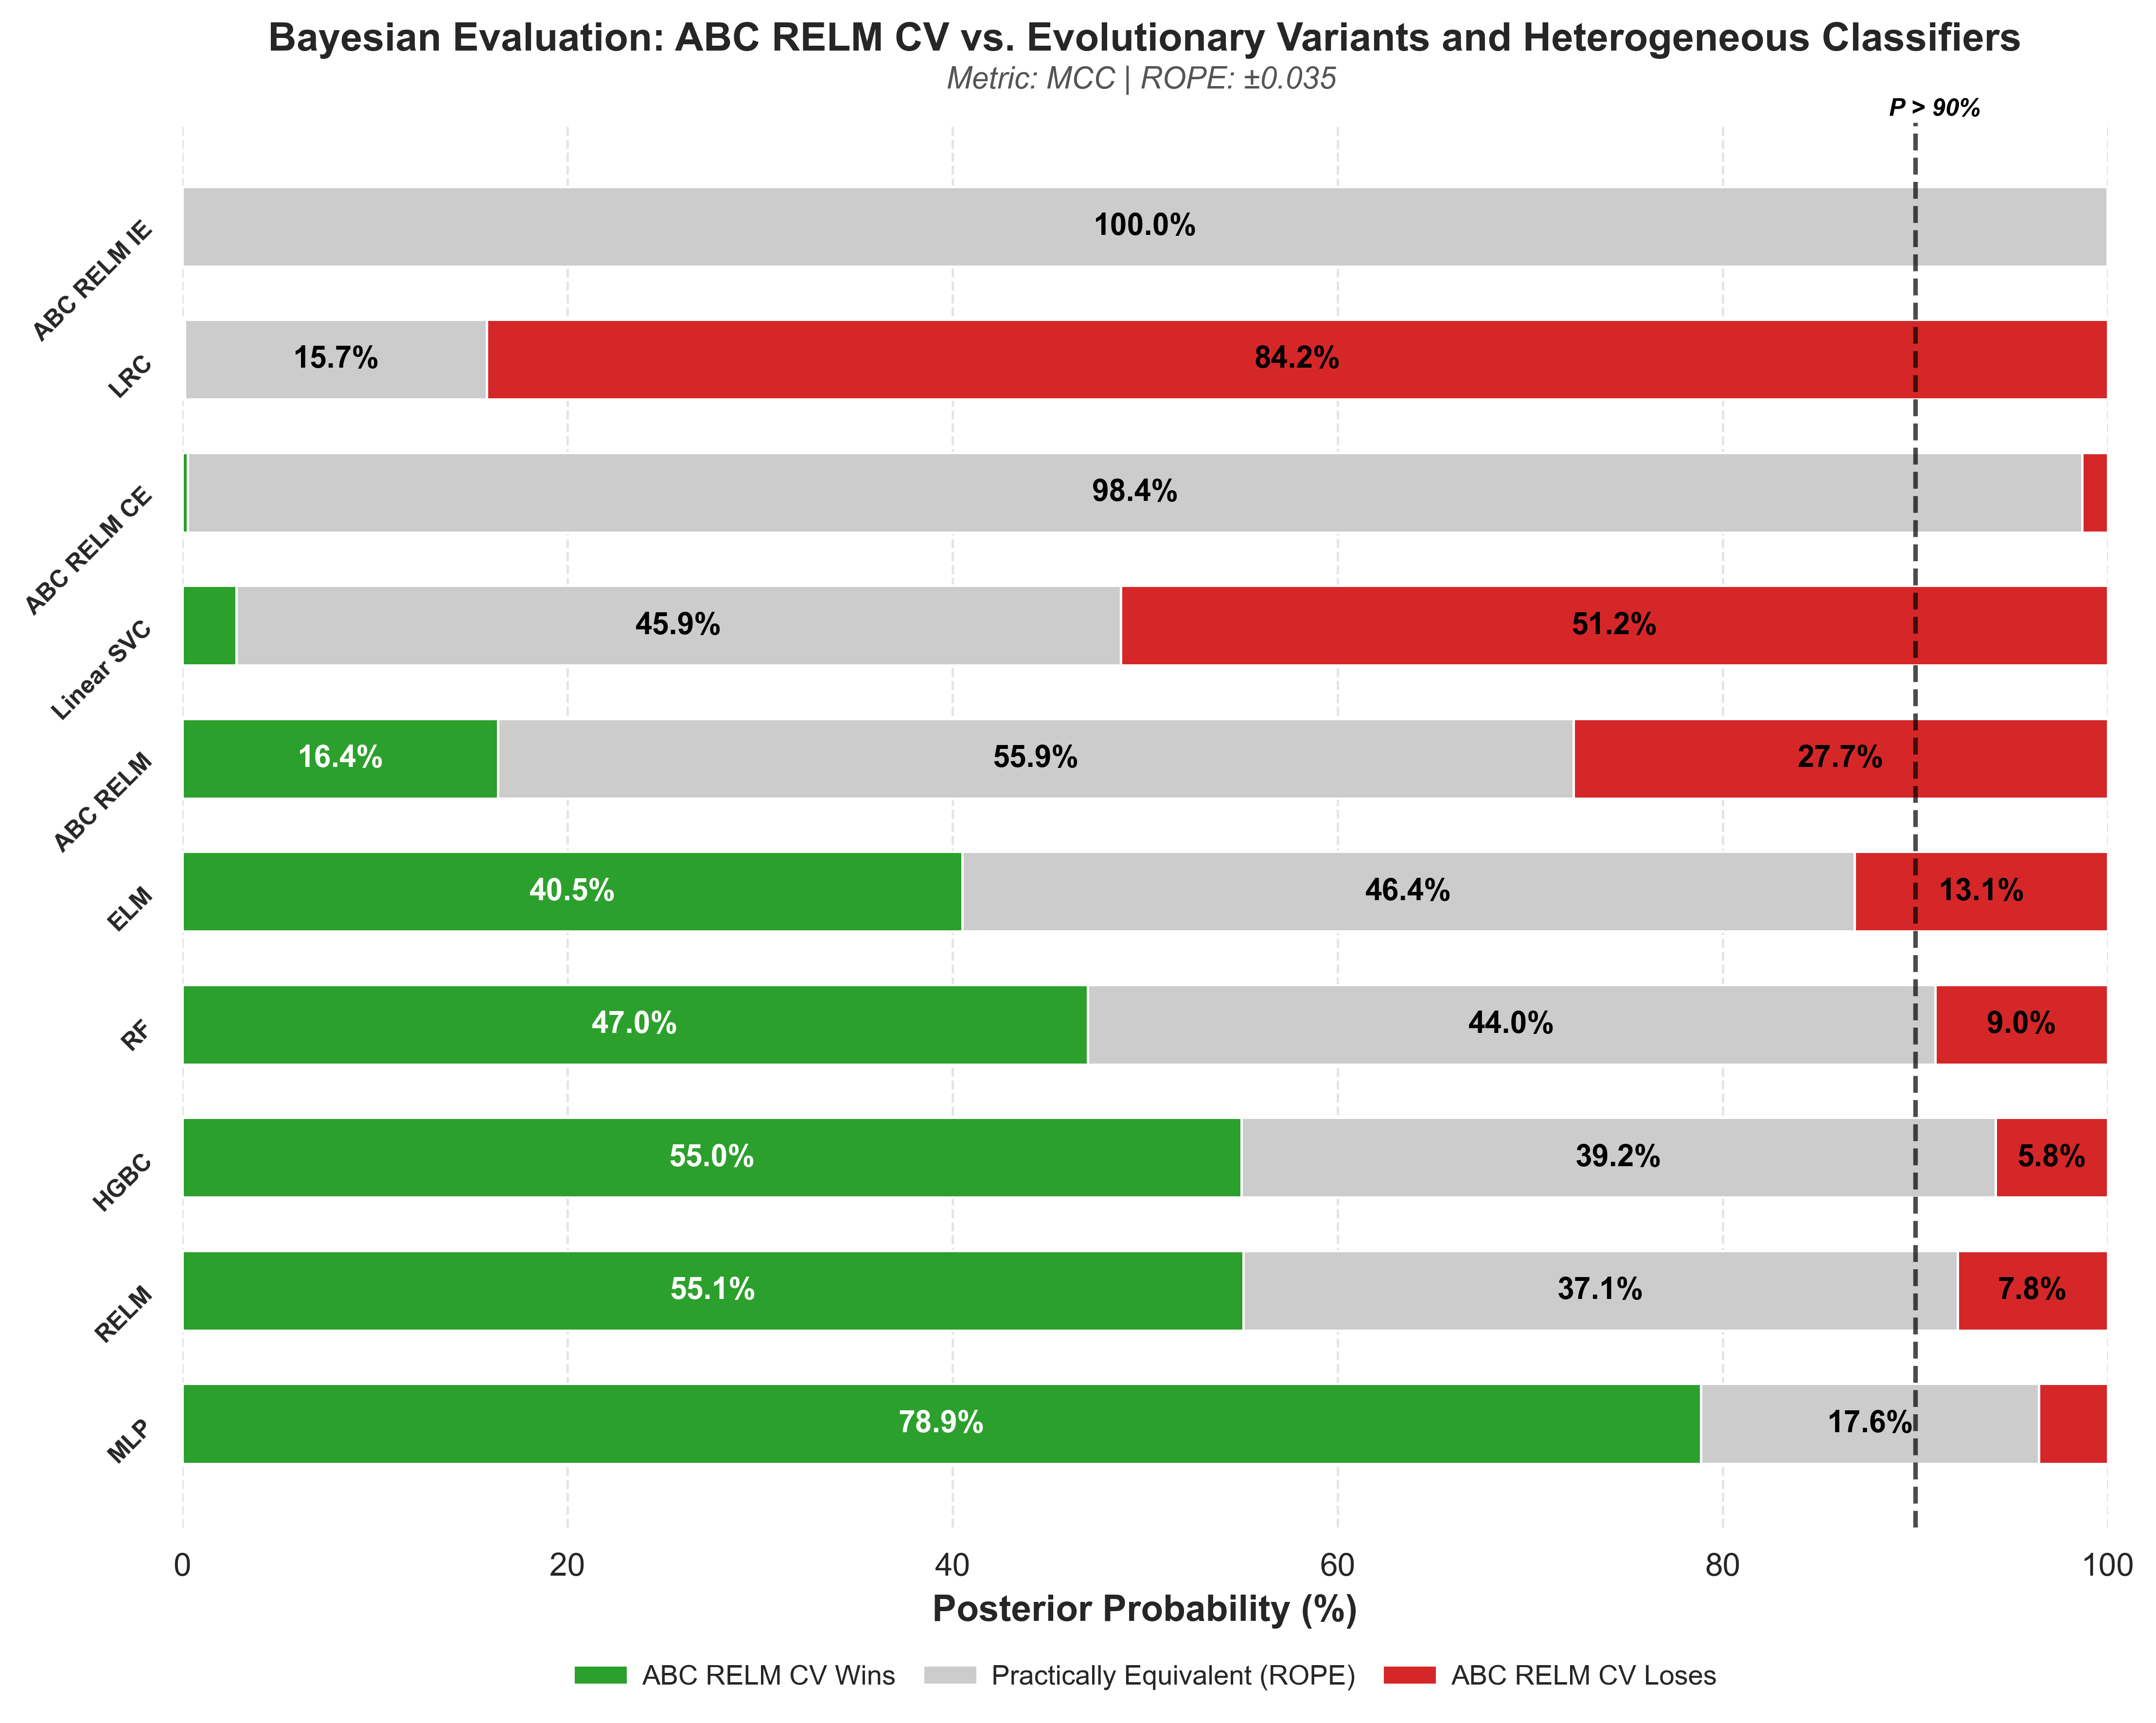

In [5]:
bayesian_result = BayesianAnalysis.run_bayesian_evaluation(
    model_dict      = model_files,
    champion_model  = "ABC RELM CV",
    baselines       = baseline,
    title           = "Bayesian Evaluation: ABC RELM CV vs. Evolutionary Variants and Heterogeneous Classifiers",
    metric_name     = 'MCC',
    rope_radius     = 0.035,
    certainty_threshold = 0.9,
    is_final_record     = True
)

In [6]:
final_result_summary = final_df = result_summary.merge(bayesian_result[['P_Win']],
                         left_on='model_name', right_index=True, how='left')

In [7]:
sequence_baseline = baseline[::-1]
full_order = ["ABC RELM CV"] + sequence_baseline

final_result_summary['model_name'] = pd.Categorical(
    final_result_summary['model_name'],
    categories = full_order,
    ordered = True
)
final_result_summary = final_result_summary.sort_values('model_name')

report_summary = ABC_Testing.format_summaries_for_academic_report(final_result_summary)
report_summary

,model_name,Accuracy,F1-Score,MCC,P_Win
0,ABC RELM CV,0.7939 ± 0.0423,0.7739 ± 0.0474,0.5947 ± 0.0853,NaN
5,ABC RELM IE,0.7938 ± 0.0421,0.7738 ± 0.0470,0.5947 ± 0.0850,0.000026
9,LRC,0.8301 ± 0.0429,0.8161 ± 0.0535,0.6644 ± 0.0817,0.001331
6,ABC RELM CE,0.7957 ± 0.0416,0.7755 ± 0.0466,0.5986 ± 0.0839,0.002886
10,Linear SVC,0.8143 ± 0.0583,0.8018 ± 0.0652,0.6309 ± 0.1163,0.028019
4,ABC RELM,0.7976 ± 0.0391,0.7765 ± 0.0462,0.6034 ± 0.0777,0.163819
2,ELM,0.7825 ± 0.0307,0.7616 ± 0.0367,0.5721 ± 0.0606,0.405118
7,RF,0.7809 ± 0.0326,0.7714 ± 0.0289,0.5634 ± 0.0661,0.470225
8,HGBC,0.7756 ± 0.0286,0.7635 ± 0.0287,0.5537 ± 0.0569,0.549949
3,RELM,0.7734 ± 0.0338,0.7532 ± 0.0371,0.5528 ± 0.0680,0.551029
